### Dataset preparation    
1. split dataset into traset and valset. 
2. show the distribution of the dataset. 

In [1]:
import rasterio
import numpy as np
from glob import glob
import geopandas as gpd
import cartopy.crs as ccrs
from pyrsimg import imgShow
import matplotlib.pyplot as plt
from shapely.geometry import Point    
import cartopy.feature as cfeature      
from rasterio.warp import transform


In [2]:
### get the secene and truth pairwise data
dir_scene = 'data/dset/scene/scene_nor' 
dir_truth = 'data/dset/truth/truth_tif' 
dir_dset_split = 'data/dset/dset_split' 
paths_scene = sorted(glob(dir_scene+'/*/*.tif'))
paths_truth = sorted(glob(dir_truth+'/*/*.tif'))
print(len(paths_scene))
print(len(paths_truth)) 


215
215


#### 2. dataset split into traset and valset(5:1)    


In [4]:
ids_scene = sorted([path.split('/')[-1].split('.')[0] for path in paths_scene])
ids_scene_val = ids_scene[::5]        ## every 10th scene for validation
ids_scene_tra = sorted(list(set(ids_scene) - set(ids_scene_val)))
print(f'train data: {len(ids_scene_tra)}, vali data: {len(ids_scene_val)}')
print('train data: ', ids_scene_val)      
print('test data: ', ids_scene_tra)   


train data: 172, vali data: 43
train data:  ['S2A_L2A_20190125_N0211_R034_S1', 'S2A_L2A_20190206_N0211_R067_S3', 'S2A_L2A_20190318_N0211_R061_S2', 'S2A_L2A_20190429_N0211_R096_S1', 'S2A_L2A_20190508_N0212_R078_S3', 'S2A_L2A_20190716_N0213_R063_S2', 'S2A_L2A_20190725_N0213_R054_S1', 'S2A_L2A_20190811_N0213_R013_S2', 'S2A_L2A_20190817_N0213_R089_S4', 'S2B_L2A_20181226_N0211_R102_S2', 'S2B_L2A_20190303_N0211_R065_S1', 'S2B_L2A_20190430_N0211_R035_S3', 'S2B_L2A_20190607_N0212_R012_S2', 'S2B_L2A_20190620_N0212_R053_S1', 'S2B_L2A_20190801_N0213_R084_S3', 'S2B_L2A_20190811_N0213_R079_S2', 'S2B_L2A_20190831_N0213_R082_S1', 'S2B_L2A_20190904_N0213_R132_S3', 'S2B_L2A_20191015_N0213_R007_S2', 'l5_scene_01', 'l5_scene_06', 'l5_scene_11', 'l5_scene_16', 'l5_scene_21', 'l5_scene_26', 'l7_scene_01', 'l7_scene_06', 'l7_scene_11', 'l7_scene_16', 'l7_scene_21', 'l7_scene_26', 'l8_scene_01', 'l8_scene_06', 'l8_scene_11', 'l8_scene_16', 'l8_scene_21', 'l8_scene_26', 'l9_scene_01', 'l9_scene_06', 'l9_scene

In [5]:
import shutil
for id_scene in ids_scene:
  path_scene = f'{dir_scene}/{id_scene[0:2].lower()}/{id_scene}.tif'
  path_truth = f'{dir_truth}/{id_scene[0:2].lower()}/{id_scene}_truth.tif'
  if id_scene in ids_scene_tra:    
    path_scene_copy = dir_dset_split + '/train/scene'      
    path_truth_copy = dir_dset_split + '/train/truth'      
  elif id_scene in ids_scene_val:       
    path_scene_copy = dir_dset_split + '/val/scene'        
    path_truth_copy = dir_dset_split + '/val/truth'       
  shutil.copy(path_scene, path_scene_copy)     
  shutil.copy(path_truth, path_truth_copy)     
  print('scene copy to: ', path_scene_copy)      
  print('truth copy to: ', path_truth_copy)      



scene copy to:  data/dset/dset_split/val/scene
truth copy to:  data/dset/dset_split/val/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/val/scene
truth copy to:  data/dset/dset_split/val/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/dset_split/train/scene
truth copy to:  data/dset/dset_split/train/truth
scene copy to:  data/dset/ds

#### check dataset distribution

In [6]:
def get_image_center_wgs84(path_tif):
    scene_id = path_tif.split('/')[-1].split('.')[0] 
    with rasterio.open(path_tif) as src:
        center_x = src.width / 2
        center_y = src.height / 2
        center_lon, center_lat = src.xy(center_y, center_x)        
        center = (center_lon, center_lat)
        if src.crs and src.crs.to_epsg() != 4326:
            from_crs = src.crs.to_string()
            to_crs = "EPSG:4326"  # WGS84
            lon, lat = transform(from_crs, to_crs, [center_lon], [center_lat])
            center = (lon[0], lat[0])
            return center, scene_id
        else:
            return center, scene_id


In [7]:
## get scene locations
paths_truth_tif = sorted(glob(dir_truth+'*/*.tif')) 
scene_centers, scene_ids = zip(*[get_image_center_wgs84(path) for path in paths_scene])
print(scene_ids[0], scene_centers[0])   


l5_scene_01 (119.5704867729241, -29.095217192439915)


In [8]:
## get scene label (tra/val)
labels_scene = ids_scene.copy() 
for i, scene_id in enumerate(ids_scene):
  if scene_id in ids_scene_tra:
    labels_scene[i] = 'tra'
  elif scene_id in ids_scene_val:
    labels_scene[i] = 'val'
print(labels_scene)


['val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra', 'tra', 'tra', 'val', 'tra', 'tra'

In [9]:
dset_gdf = gpd.GeoDataFrame({
  'scene_id': [scene_id for scene_id in scene_ids],
  'satellite': [scene_id[0:2].lower() for scene_id in scene_ids],
  'type': labels_scene,
  'geometry': [Point(center) for center in scene_centers],
      }, 
  crs='EPSG:4326')
# dset_gdf.to_file('data/dset/dset.gpkg', driver='GPKG') 
dset_gdf.head(5)


,scene_id,satellite,type,geometry
0,l5_scene_01,l5,val,POINT (119.57049 -29.09522)
1,l5_scene_02,l5,tra,POINT (66.38197 59.88031)
2,l5_scene_03,l5,tra,POINT (61.77425 46.04525)
3,l5_scene_04,l5,tra,POINT (125.44233 63.95019)
4,l5_scene_05,l5,tra,POINT (113.91528 22.58003)


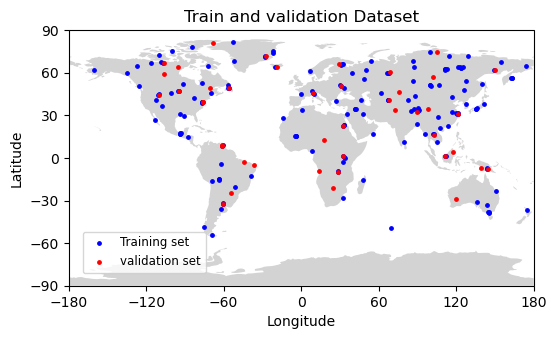

In [16]:
fig, ax = plt.subplots(figsize=(6, 4), 
                subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.set_extent([-180, 180, -90, 90])
dset_gdf[dset_gdf['type']=='tra'].plot(ax=ax, 
                    markersize=6, 
                    color='blue',
                    label='Training set')
dset_gdf[dset_gdf['type']=='val'].plot(ax=ax, 
                    markersize=6, 
                    color='red',
                    label='validation set')

ax.set_title('Train and validation Dataset')
ax.legend(loc=(0.03,0.05), fontsize=8.5)
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.tick_params(labelsize=10)
# fig.savefig('figs/dset_split.png', dpi=300)
